# CN2 - RÉSOLUTION NUNÉRIQUE DE L'ÉQUATION DE DIFFUSION THERMIQUE


On s'intéresse ici à une barre métallique cylindrique de longueur $L=1m$, dont la
 surface latérale est calorifugée. Les deux extrémités gauche et droite de la barre sont au contact
de glace fondante de température $T_g = 0°C$, qui joue le rôle de thermostat. 

L’objectif de cet exercice est de résoudre numériquement l’équation de la diffusion thermique dans cette situation simple.



## A) Rappel théorique

### Problème à résoudre

 On rappelle que l'équation de diffusion thermique s'écrit

$$
\boxed{
\frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2}
}$$

où $T(t,x)$ représente la température et $\kappa$ désigne la diffusivité thermique. Il s'agit d'une équation aux dérivées partielles (EDP) :
* d'ordre 1 en temps $t$ ;
* d'ordre 2 en espace $x$.

Il donc faut adjoindre à cette équation une condition initiale $T(t=0,x)$ et les deux conditions aux limites $T(t,x=0)=T_g$ et $T(t,x=L)=T_g$.
On considérera un matériau de coefficient de diffusivité thermique $\kappa=10^{-4} m^2.s^{-1}$.



### Rappel sur la méthode d'Euler

On sait résoudre analytiquement l'équation de diffusion thermique dans la plupart des situations, mais la démonstration est difficile et les fonctions utilisées font intervenir des intégrales de Gauss, qu'il est nécessaire d'évaluer numériquement dans tous les cas. Il est donc pertinent d'essayer de résoudre l'équation de la diffusion thermique de façon approchée, par une méthode **numérique**, d'autant que ces méthodes se généralisent à toute sorte d'équations différentielles. Nous utilissons ici la méthode des **différences finie**, qui est une généralisation de la méthode d'Euler vue en PCSI pour les **équations aux dérivées partielles (EDP)**.


La méthode d'Euler est une procédure numérique qui permet de résoudre de façon approximative des équations différentielles ordinaires du premier ordre avec condition initiale. Considérons l'équation différentielle 
$$
\boxed{
\frac{\mathrm{d} y}{\mathrm{d} t}(t) = f(y(t)).
}
$$
avec condition initiale $y(t=0)=y_0$ et $f$ une fonction régulière. La résolution numérique de cette équation passe par les étapes suivantes :
* discrétisation du temps $t$ en instants $t_n$ séparés par un pas de durée élémentaire $\mathrm{d} t$ ;
* discrétisation de l'opérateur de dérivation $\frac{\mathrm{d} y}{\mathrm{d} t}$ : on approxime la dérivée par une différence finie (taux d'accroissement) 
$$\frac{\mathrm{d} y}{\mathrm{d} t} \simeq \frac{y(t_{n+1}) - y(t_n)}{\mathrm{d} t}.$$
* calcul itératif des valeurs de $y_n=y(t_n)$ d'après l'équation
$$
y_{n+1} \simeq y_n + f(y_n) \mathrm{d} t.
$$

La méthode d'Euler présentée ici (méthode explicite) est simple à implémenter mais présente un gros défaut de divergence de la solution numérique. En pratique, elle n'est pas utilisée pour des résolutions précises. La méthode des **différences finies** que nous allons présenter a aussi ce défaut, mais nous admettrons que la solution numérique converge bien aux temps longs avec les valeurs des paramètres que nous choisirons. Pour davantage d'information sur la **méthode d'Euler**, consulter : https://femto-physique.fr/analyse-numerique/euler.php.


## B) Résolution numérique par la méthode des différences finies



><span style="color:red;">ATTENTION </span>: Nous représenterons la température par un tableau de type ```numpy.array```. On aura de plus besoin du module ```matplotlib.pyplot``` pour tracer les graphes de la température. On importe donc ces bibliothèques python au préablable : 



In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Discrétisation

Soit $L=1\,m$ la longueur de la barre et $\Delta t = 30\,min$ la durée de l'expérience. On discrétise l'espace et le temps de la façon suivante.
* l'intervalle $[0,\Delta t]$ est découpé en $N_t$ instants $t_i = i\cdot\mathrm{d} t$ séparées par un pas temporel $\mathrm{d} t = 0,4\,s$.
* l'intervalle $[0,L]$ est découpé en $N_x$ positions $x_j = j\cdot\mathrm{d}x$ séparées par un pas spatiale $\mathrm{d} x = 0,01\,m$,

>**Question 1**
>
>Compléter les lignes suivantes pour définir les variables ```Nx``` et ```Nt``` à partir des variables ```dx```, ```L```, ```dt``` et ```Deltat```. Les durées sont exprimées en seconde et les longueurs en mètre.

> 
><span style="color:red;">ATTENTION </span>: les variables ```Nx``` et ```Nt``` doivent être de type *int* (entier) !
>

In [ ]:
dx = 1e-2
dt = 4e-1
L  = 1
Deltat = 30*60

# solution
Nx = int(L/dx) + 1
Nt = int(Deltat/dt) + 1

> **Question 2** 
>
> Créer un tableau ```T``` de type ```numpy.array``` rempli de zéros, à l'aide de la fonction ```np.zeros```. Chaque valeur ```T[i,j]``` représentera la valeur de la température $T(t,x)$ aux instants et positions $t_i = i\cdot dt$ et $x_j =  j\cdot dx$. On pourra consulter le lien ci-dessous pour l'utilisation de la fonction ```np.zeros``` :
https://numpy.org/doc/2.0/reference/generated/numpy.zeros.html.
> 
> Créer également les tableaux ```t``` et ```x```, de type ```numpy.array```, correspondant respectivement aux instants $t_i$ et aux positions $x_j$ pour lesquels la température est évaluée. On utilisera les variables ```Nx```, ```Nt```, ```L``` et ```Deltat``` définies précédemment, et on se servira de fonctions ```np.linspace``` : https://numpy.org/doc/2.0/reference/generated/numpy.linspace.html#numpy-linspace.

In [ ]:
# solution
T = np.zeros((Nt,Nx))
t = np.array([i*dt for i in range(Nt)])
x = np.array([j*dx for j in range(Nx)])

### Initialisation

>**Question 3**
>
>On suppose que le profil **initial** de température a une forme sinusoïdale, d'expression 
$$
\boxed{
T(t=0,x) = T_g + T_0 \sin (2\pi x/L),
}
$$
où l'amplitude des variations de température vaut $T_0 = 20°C$ et la température de la glace fondante vaut $T_g = 0°C$.
>
> Définir les variables ```T_0``` et ```Tg```, puis remplir la première ligne ```T[0,:]``` du tableau ```T``` pour spécifier les conditions initiales de l'expérience. On pourra utiliser la fonction ```np.sin```.

In [ ]:
T0 = 20
Tg = 0
T[0,:] = Tg + T0*np.sin(2*np.pi*x/L) # on remplit le tableau pour i=0 (instant initial)

>**Question 4**
>
>Compléter le code suivant pour tracer l'évolution de la température initiale au sein de la barre.

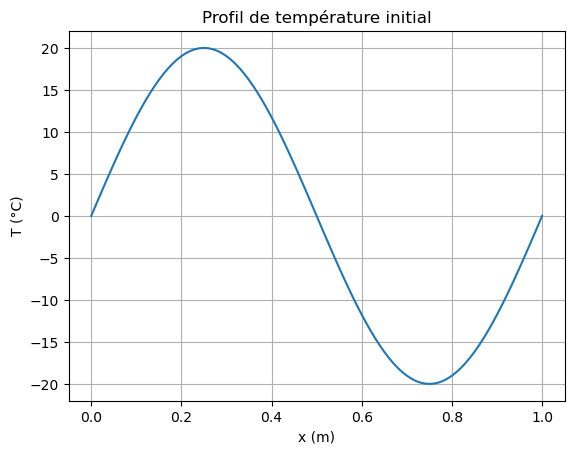

In [5]:
plt.close()
plt.figure()
plt.grid()
plt.xlabel("x (m)")
plt.ylabel("T (°C)")
plt.title("Profil de température initial")
# solution
plt.plot(x,T[0,:])
# fin solution
plt.show()

### Itérations

>**Question 5**
>
> **Conditions aux limites**. 
> Remplir les colonnes ```T[:,0]``` et ```T[:,-1]``` tableau ```T``` de manière à imposer, à tout instant, les conditions aux limites aux deux extrémités de la barre, $T(x=0,t)=T_g$ et $T(x=L,t)=T_g$.

In [ ]:
for i in range (1,Nt): # l'instant initial a déjà été traité
    T[i,0]  = Tg       # T vaut Tg=0 en x=0 à tout instant
    T[i,-1] = Tg       # T vaut Tg=0 en x=L à tout instant

Il s'agit donc désormais de résoudre l'équation :
$$\boxed{\frac{\partial T}{\partial t} = \kappa \frac{\partial^2 T}{\partial x^2}.}$$


>**Question 6**
>
> En assimilant la dérivée temporelle à un taux d'accroissement, exprimer $\dfrac{\partial T}{\partial t}(t=i\mathrm{d}t,x=j\mathrm{d}x)$ en fonction de `T[i,j]` et de `T[i+1,j]`.

> 
><span style="color:red;">ATTENTION </span>: question à réaliser sur une feuille de papier !
>

><span style="color:red;"> Solution </span>
>$$\boxed{\dfrac{\partial T}{\partial t}(t=i\mathrm{d}t,x=j\mathrm{d}x) \simeq \frac{T[i+1,j]-T[i,j]}{dt}}$$

>**Question 7**
>
>  Soit une fonction $f$. En écrivant la formule de Taylor à l’ordre 2 pour $f(x+dx)$ et $f(x-dx)$, démontrer que : 
> $$ f''(x)\simeq\frac{f(x+dx)+f(x-dx)-2f(x)}{dx^2}$$

> 
><span style="color:red;">ATTENTION </span>: question à réaliser sur une feuille de papier !
>

><span style="color:red;"> Solution </span>
>
> On a 
$$
f''(x+\mathrm{d} x) = f(x) + f'(x) \mathrm{d} x + f''(x) \frac{\mathrm{d}x^2}{2} + o(\mathrm{d}x^2)
$$
$$
f''(x-\mathrm{d} x) = f(x) - f'(x) \mathrm{d} x + f''(x) \frac{\mathrm{d}x^2}{2} + o(\mathrm{d}x^2)
$$
En sommant les deux expressions, on trouve
$$
f''(x+\mathrm{d} x) + f''(x-\mathrm{d} x) \simeq  2 f(x) + f''(x)\mathrm{d}x^2,
$$
d'où le résultat : 

$$ \boxed{f''(x)\simeq\frac{f(x+dx)+f(x-dx)-2f(x)}{dx^2}}$$

>**Question 8**
>
> En déduire l'approximation de $\dfrac{\partial^2 T}{\partial x^2}(t=i\mathrm{d}t,x=j\mathrm{d}x)$ en fonction de `T[i,j]`, de `T[i,j+1]` et de `T[i,j-1]`.

> 
><span style="color:red;">ATTENTION </span>: question à réaliser sur une feuille de papier !
>

><span style="color:red;"> Solution </span>
> $$\boxed{\dfrac{\partial^2 T}{\partial x^2}(t=i\mathrm{d}t,x=j\mathrm{d}x) \simeq \frac{T[i,j+1]+T[i,j-1]-2T[i,j]}{dx^2}}$$

> **Question 9**
>
> En déduire que la résolution de l'équation de diffusion thermique dans la barre se ramène au schéma numérique :
> $$\boxed{T[i+1,j]=T[i,j]+\frac{\kappa \mathrm{d}t}{\mathrm{d}x^2} \left( T[i,j+1]+T[i,j-1]-2T[i,j]\right)}$$

> 
><span style="color:red;">ATTENTION </span>: question à réaliser sur une feuille de papier !
>

><span style="color:red;"> Solution </span>
>
>On remplace les dérivées dans l'équation de diffusion thermique par les différences finies calculées ci-dessus, soit 
$$
\frac{\partial T}{\partial t}(t=i\mathrm{d}t,x=j\mathrm{d}x) = \kappa \frac{\partial^2 T}{\partial x^2}(t=i\mathrm{d}t,x=j\mathrm{d}x) \Rightarrow   \frac{T[i+1,j]-T[i,j]}{dt} \simeq \kappa\frac{T[i,j+1]+T[i,j-1]-2T[i,j]}{dx^2},
$$
d'où le résultat,
> $$\boxed{T[i+1,j]=T[i,j]+\frac{\kappa \mathrm{d}t}{\mathrm{d}x^2} \left( T[i,j+1]+T[i,j-1]-2T[i,j]\right)}$$

### Implémentation du schéma numérique

On peut montrer qu'un tel schéma numérique converge à la condition que 

$$\boxed{\frac{\kappa dt}{dx^2}<\frac{1}{2}}.$$ Avec les valeurs de $dx$ et de $dt$ choisies, cette condition est respectée pour la valeur choisie de la diffusivité thermique $\kappa=10^{-4} m^2.s^{-1}$.

>**Question 10**
>
> Implémenter ce schéma numérique pour remplir le tableau ```T``` dans son intégralité. Pour cela, on calculera à chaque instant $t=i \mathrm{d} t$ et pour chaque position ```j``` la température ```T[i+1,j]``` à l'instant $t=(i+1)\mathrm{d}t = t + \mathrm{d}t$ suivant, selon l'équation trouvée en **question 9**.

In [7]:
kappa = 1e-4

for i in range(0,Nt-1): # itération sur les instants i
    for j in range(1,Nx-1): # itération sur les positions j
        # solution
        T[i+1,j]=T[i,j]+kappa*dt/(dx**2)*(T[i,j+1]+T[i,j-1]-2*T[i,j])
        # fin solution

>**Question 11**
>
>On souhaite tracer le profil de température aux différents instants définis dans la liste ```instants``` ci-dessous. Compléter la boucle du suivant code de sorte à tracer sur un même graphique l'évolution du profil de température dans le temps. Comparer la solution analytique (admise)
$$
\boxed{
T(t,x) = T_g + T_0 e^{-t/\tau} sin(2\pi x/L),
}
$$
avec $\tau = {L^2}/({4\pi^2\kappa})$.

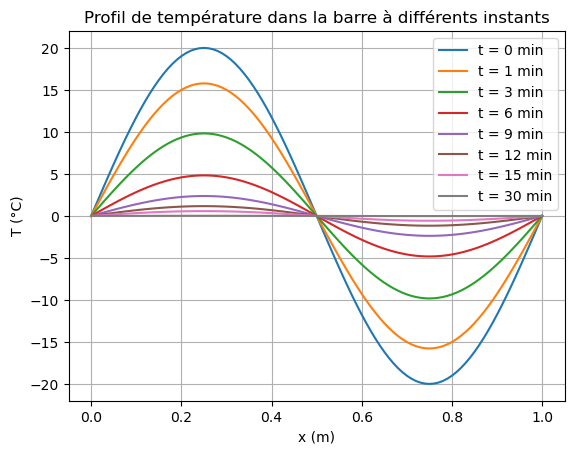

In [8]:
plt.close()
plt.figure()
plt.xlabel("x (m)")
plt.ylabel("T (°C)")
plt.title("Profil de température dans la barre à différents instants")

instants = [0,1,3,6,9,12,15,30] # instants choisis en minutes
for t in instants: # tracé du profil du température aux instants choisis
    i = int(t*60/dt)
    # solution
    plt.plot(x,T[i,:],label="t = "+str(t)+" min") # on étiquette chaque courbe avec la valeur de l'instant t
    # fin solution
plt.legend()
plt.grid()
plt.show()

><span style="color:red;"> Solution </span>
>
>Les graphes semblent cohérents avec une décroissance exponentielle de la température dans le temps,
$$
T(t,x) = T_g + T_0 e^{-t/\tau} sin(2\pi x/L).
$$
Le temps typique de décroissance vaut ici $\tau = {L^2}/({4\pi^2\kappa}) \simeq  4$ min $13$ s. Cela signifie que l'amplitude de la variation spatiale de température doit diminuer d'un facteur $e\simeq2$,$7$ au bout de $\simeq 4$ min, ce qui est cohérent avec la figure.